# March Madness 2026 — Refined Pipeline

### What we learned from the first attempt (03_modeling)

Our simple **logistic regression** (MSE 0.1447) beat every complex model we tried — XGBoost, LightGBM, and the ensemble all scored ~0.153. Why?

1. **Only ~130 tournament games per year** — complex models overfit on this tiny dataset
2. **Seed difference is the #1 feature** by a huge margin — the selection committee already did most of the work
3. **GLM quality values were overflowing** (1e16 scale) — now fixed with L2 regularization + z-score normalization
4. **Massey ordinals are men-only** — half our training data (women) got zeros, misleading the model

### This notebook's approach

- **Multi-year validation** — test on 2023, 2024, AND 2025 holdouts (not just 2025)
- **Experiment tracking** — log every model variant so we can see exactly what helps
- **Start simple, add complexity only if it helps ALL holdout years**
- **Separate men's/women's Massey handling** — men get Massey, women get a seed-based proxy

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.model_selection import GroupKFold
import xgboost as xgb
import lightgbm as lgb

sys.path.insert(0, '..')
from src import data_loader, features, models, utils

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

print('Ready to go!')

Ready to go!


---
## Experiment Tracker

Every model variant we try gets logged here. We track MSE on **three holdout years** so we can see if an improvement is real or just got lucky on one year. A change only counts as an improvement if it helps on **at least 2 of 3** holdout years.

In [2]:
# Experiment tracker — every model run gets logged here
experiments = []

def log_experiment(name, description, val_results, model_obj=None):
    """Log a model experiment with MSE on each holdout year.
    
    val_results: dict of {year: {'mse': float, 'accuracy': float, 'n_games': int}}
    """
    entry = {
        'name': name,
        'description': description,
        'model': model_obj,
    }
    mses = []
    for year, metrics in val_results.items():
        entry[f'MSE_{year}'] = metrics['mse']
        entry[f'Acc_{year}'] = metrics.get('accuracy', None)
        mses.append(metrics['mse'])
    entry['MSE_avg'] = np.mean(mses)
    experiments.append(entry)
    
    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"  {description}")
    print(f"{'='*60}")
    for year, metrics in val_results.items():
        acc_str = f", Acc={metrics['accuracy']:.1%}" if 'accuracy' in metrics else ''
        print(f"  {year}: MSE={metrics['mse']:.6f}{acc_str}  ({metrics['n_games']} games)")
    print(f"  Average MSE: {entry['MSE_avg']:.6f}")
    print(f"{'='*60}")

def show_leaderboard():
    """Display all experiments ranked by average MSE."""
    if not experiments:
        print("No experiments logged yet.")
        return
    cols = ['name', 'description']
    cols += [c for c in experiments[0] if c.startswith('MSE_')]
    df = pd.DataFrame(experiments)[cols].sort_values('MSE_avg')
    print("\n" + "="*80)
    print("  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)")
    print("="*80)
    print(df.to_string(index=False))
    return df

HOLDOUT_YEARS = [2023, 2024, 2025]
print(f"Holdout validation years: {HOLDOUT_YEARS}")

Holdout validation years: [2023, 2024, 2025]


---
## Step 1: Load & Prepare Data

Same as before — load everything, create symmetric game rows, compute season stats. But this time we prepare **three separate validation sets** (2023, 2024, 2025 tournaments).

In [3]:
# Load raw data
regular_season = data_loader.load_regular_season()
tourney_results = data_loader.load_tourney_results()
seeds = data_loader.load_tourney_seeds()
teams = data_loader.load_teams()
sample_sub = data_loader.load_sample_submission(stage=2)

# Prepare symmetric game data (2010+)
valid = utils.valid_seasons(min_season=2010, max_season=2026)
rs_filtered = regular_season[regular_season['Season'].isin(valid)]
game_data = features.prepare_game_data(rs_filtered)

# Compute all per-team season stats
season_stats = features.compute_season_stats(game_data)
win_pct = features.compute_win_pct(game_data)
efficiency = features.compute_efficiency(game_data)
momentum = features.compute_last14_momentum(game_data)

print(f"Game data: {len(game_data):,} rows")
print(f"Teams per season: ~{season_stats.groupby('Season').size().mean():.0f}")
print(f"Seasons: {sorted(game_data['Season'].unique())}")

Game data: 327,414 rows
Teams per season: ~704
Seasons: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [4]:
# Build tournament matchups with T1_TeamID < T2_TeamID
tourney = tourney_results[tourney_results['Season'].isin(valid)].copy()
tourney = tourney[~tourney['Season'].isin([2020, 2026])].copy()

tourney['T1_TeamID'] = np.minimum(tourney['WTeamID'], tourney['LTeamID'])
tourney['T2_TeamID'] = np.maximum(tourney['WTeamID'], tourney['LTeamID'])
tourney['T1_Win'] = (tourney['WTeamID'] == tourney['T1_TeamID']).astype(int)

for yr in HOLDOUT_YEARS:
    n = (tourney['Season'] == yr).sum()
    print(f"  {yr}: {n} tournament games")
print(f"  Total: {len(tourney)} games")

  2023: 134 tournament games
  2024: 134 tournament games
  2025: 134 tournament games
  Total: 1962 games


---
## Helper: Run Experiment On Multiple Holdout Years

This function trains on all data EXCEPT the holdout year, predicts the holdout, and repeats for each holdout year. This tells us if a model generalizes — not just that it works on 2025.

In [5]:
def run_experiment(name, description, feature_names, matchup_df, 
                   model_type='logreg', model_params=None,
                   holdout_years=HOLDOUT_YEARS):
    """Train/evaluate a model on multiple holdout years.
    
    For each holdout year:
      - Train on all OTHER years
      - Predict and evaluate on the holdout year
    
    Returns the trained model (fitted on all data except 2026).
    """
    val_results = {}
    
    for hold_year in holdout_years:
        train_mask = (matchup_df['Season'] < hold_year) & (~matchup_df['Season'].isin([2020]))
        val_mask = matchup_df['Season'] == hold_year
        
        X_tr = matchup_df.loc[train_mask, feature_names].fillna(0).values
        y_tr = matchup_df.loc[train_mask, 'T1_Win'].values
        X_va = matchup_df.loc[val_mask, feature_names].fillna(0).values
        y_va = matchup_df.loc[val_mask, 'T1_Win'].values
        
        if len(X_va) == 0:
            continue
        
        if model_type == 'logreg':
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_va = scaler.transform(X_va)
            params = model_params or {'C': 1.0, 'max_iter': 1000}
            clf = LogisticRegression(**params, random_state=42)
            clf.fit(X_tr, y_tr)
            preds = clf.predict_proba(X_va)[:, 1]
            
        elif model_type == 'xgb':
            params = model_params or {
                'objective': 'binary:logistic', 'eval_metric': 'logloss',
                'eta': 0.05, 'max_depth': 3, 'subsample': 0.8,
                'colsample_bytree': 0.8, 'min_child_weight': 20,
                'verbosity': 0, 'seed': 42,
            }
            dtrain = xgb.DMatrix(X_tr, label=y_tr)
            dval = xgb.DMatrix(X_va, label=y_va)
            model = xgb.train(params, dtrain, num_boost_round=500,
                            evals=[(dval, 'val')], early_stopping_rounds=50,
                            verbose_eval=0)
            preds = model.predict(dval)
            
        elif model_type == 'lgbm':
            params = model_params or {
                'objective': 'binary', 'metric': 'binary_logloss',
                'learning_rate': 0.05, 'num_leaves': 16, 'max_depth': 3,
                'subsample': 0.8, 'colsample_bytree': 0.8,
                'min_child_samples': 20, 'verbose': -1, 'seed': 42,
            }
            dtrain = lgb.Dataset(X_tr, label=y_tr)
            dval = lgb.Dataset(X_va, label=y_va, reference=dtrain)
            model = lgb.train(params, dtrain, num_boost_round=500,
                            valid_sets=[dval],
                            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
            preds = model.predict(X_va)
        
        preds = np.clip(preds, 0.025, 0.975)
        mse = mean_squared_error(y_va, preds)
        acc = (np.round(preds) == y_va).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(y_va)}
    
    log_experiment(name, description, val_results)
    return val_results

print("Experiment runner ready.")

Experiment runner ready.


---
## Experiment 1: Seed-Only Baseline

How well can we do with **just seed difference**? This is the floor — if we can't beat this, our features aren't adding value. Historically, seed difference alone gets you in the top 50% of Kaggle submissions.

In [6]:
# Build features — seeds only
tf_seeds = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds
)
tourney_f = features.create_matchup_df(tourney, tf_seeds)
tourney_f, diff_cols = features.compute_difference_features(tourney_f)

# Experiment 1a: Just seed difference
run_experiment(
    'Seed Only (LR)', 
    'LogReg on Diff_seed only',
    ['Diff_seed'], tourney_f, 'logreg'
)


  Experiment: Seed Only (LR)
  LogReg on Diff_seed only
  2023: MSE=0.190180, Acc=69.4%  (134 games)
  2024: MSE=0.164201, Acc=76.1%  (134 games)
  2025: MSE=0.143248, Acc=79.9%  (134 games)
  Average MSE: 0.165876


{2023: {'mse': 0.19017996355932132,
  'accuracy': np.float64(0.6940298507462687),
  'n_games': 134},
 2024: {'mse': 0.16420080867126471,
  'accuracy': np.float64(0.7611940298507462),
  'n_games': 134},
 2025: {'mse': 0.14324773615606862,
  'accuracy': np.float64(0.7985074626865671),
  'n_games': 134}}

---
## Experiment 2: Core Features (What Won Phase 1)

The logistic regression feature importance showed **seed + point diff + offensive efficiency + win %** as the big 4. Let's test combinations to see which subset is best.

In [7]:
# Experiment 2a: Top 4 features from Phase 1
top4 = ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct']
run_experiment(
    'Top4 (LR)',
    'LogReg on seed + PointDiff + OffEff + WinPct',
    top4, tourney_f, 'logreg'
)


  Experiment: Top4 (LR)
  LogReg on seed + PointDiff + OffEff + WinPct
  2023: MSE=0.181327, Acc=73.9%  (134 games)
  2024: MSE=0.166476, Acc=73.9%  (134 games)
  2025: MSE=0.139637, Acc=83.6%  (134 games)
  Average MSE: 0.162480


{2023: {'mse': 0.18132729506271003,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2024: {'mse': 0.16647605830090106,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.13963727017279837,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 134}}

In [8]:
# Experiment 2b: Top4 + defensive efficiency + momentum
top6 = top4 + ['Diff_DefEff', 'Diff_win_ratio_14d']
run_experiment(
    'Top6 (LR)',
    'LogReg on top4 + DefEff + momentum',
    top6, tourney_f, 'logreg'
)


  Experiment: Top6 (LR)
  LogReg on top4 + DefEff + momentum
  2023: MSE=0.181954, Acc=73.9%  (134 games)
  2024: MSE=0.166526, Acc=74.6%  (134 games)
  2025: MSE=0.139167, Acc=83.6%  (134 games)
  Average MSE: 0.162549


{2023: {'mse': 0.18195423916334635,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2024: {'mse': 0.16652566358195933,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.13916741165934132,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 134}}

In [9]:
# Experiment 2c: All difference features (what we ran in Phase 1 of 03_modeling)
all_diff = [f for f in diff_cols if tourney_f[f].notna().mean() > 0.9]
run_experiment(
    'All Diff (LR)',
    f'LogReg on all {len(all_diff)} diff features',
    all_diff, tourney_f, 'logreg'
)


  Experiment: All Diff (LR)
  LogReg on all 20 diff features
  2023: MSE=0.188309, Acc=73.1%  (134 games)
  2024: MSE=0.169386, Acc=71.6%  (134 games)
  2025: MSE=0.144699, Acc=81.3%  (134 games)
  Average MSE: 0.167465


{2023: {'mse': 0.18830898749603533,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16938638528740696,
  'accuracy': np.float64(0.7164179104477612),
  'n_games': 134},
 2025: {'mse': 0.1446993871641639,
  'accuracy': np.float64(0.8134328358208955),
  'n_games': 134}}

---
## Experiment 3: XGBoost (Shallow & Constrained)

The lesson from Phase 2 was that XGBoost overfits with default settings. Let's constrain it aggressively:
- **max_depth=2** (very shallow trees)
- **min_child_weight=30** (need 30+ samples per leaf)
- **Only use the top 4-6 features** (less room to overfit)

The idea: use XGBoost's ability to find non-linear interactions, but don't give it enough rope to hang itself.

In [10]:
# Experiment 3a: Shallow XGBoost on top 4 features
xgb_conservative = {
    'objective': 'binary:logistic', 'eval_metric': 'logloss',
    'eta': 0.03, 'max_depth': 2, 'subsample': 0.7,
    'colsample_bytree': 1.0, 'min_child_weight': 30,
    'gamma': 5, 'verbosity': 0, 'seed': 42,
}

run_experiment(
    'Top4 (XGB shallow)',
    'XGBoost depth=2, min_child=30 on top4',
    top4, tourney_f, 'xgb', xgb_conservative
)


  Experiment: Top4 (XGB shallow)
  XGBoost depth=2, min_child=30 on top4
  2023: MSE=0.182052, Acc=70.9%  (134 games)
  2024: MSE=0.160572, Acc=73.9%  (134 games)
  2025: MSE=0.143740, Acc=82.1%  (134 games)
  Average MSE: 0.162121


{2023: {'mse': 0.18205226957798004,
  'accuracy': np.float64(0.7089552238805971),
  'n_games': 134},
 2024: {'mse': 0.16057217121124268,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.14373955130577087,
  'accuracy': np.float64(0.8208955223880597),
  'n_games': 134}}

In [11]:
# Experiment 3b: Shallow XGBoost on top 6
run_experiment(
    'Top6 (XGB shallow)',
    'XGBoost depth=2, min_child=30 on top6',
    top6, tourney_f, 'xgb', xgb_conservative
)


  Experiment: Top6 (XGB shallow)
  XGBoost depth=2, min_child=30 on top6
  2023: MSE=0.183086, Acc=72.4%  (134 games)
  2024: MSE=0.159119, Acc=74.6%  (134 games)
  2025: MSE=0.142754, Acc=80.6%  (134 games)
  Average MSE: 0.161653


{2023: {'mse': 0.1830863654613495,
  'accuracy': np.float64(0.7238805970149254),
  'n_games': 134},
 2024: {'mse': 0.15911850333213806,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.1427539438009262,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 134}}

In [12]:
# Experiment 3c: Shallow LightGBM on top 6
lgb_conservative = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'learning_rate': 0.03, 'num_leaves': 8, 'max_depth': 2,
    'subsample': 0.7, 'colsample_bytree': 1.0,
    'min_child_samples': 30, 'verbose': -1, 'seed': 42,
}

run_experiment(
    'Top6 (LGBM shallow)',
    'LightGBM depth=2, min_child=30 on top6',
    top6, tourney_f, 'lgbm', lgb_conservative
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[238]	valid_0's binary_logloss: 0.538348
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[239]	valid_0's binary_logloss: 0.486295
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[498]	valid_0's binary_logloss: 0.436246

  Experiment: Top6 (LGBM shallow)
  LightGBM depth=2, min_child=30 on top6
  2023: MSE=0.182140, Acc=73.1%  (134 games)
  2024: MSE=0.162536, Acc=73.9%  (134 games)
  2025: MSE=0.143271, Acc=79.9%  (134 games)
  Average MSE: 0.162649


{2023: {'mse': 0.18213990260864635,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.1625364330535013,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.14327054819045776,
  'accuracy': np.float64(0.7985074626865671),
  'n_games': 134}}

---
## Experiment 4: Add GLM Quality (Now Fixed)

The GLM team quality metric was overflowing before (values of 1e16). Now it's regularized with L2 penalty and z-score normalized. Let's see if it actually helps.

In [13]:
# Compute GLM quality with the fixed regularized version
print("Computing GLM team quality (regularized)...")
quality = features.compute_team_quality(game_data, seeds)
print(f"Quality range: [{quality['quality'].min():.2f}, {quality['quality'].max():.2f}]")
print(f"Quality std: {quality['quality'].std():.2f} (should be ~1.0 if z-scored)")

# Top 5 per recent seasons
for yr in [2024, 2025]:
    top = quality[quality['Season'] == yr].nlargest(5, 'quality')
    top['name'] = top['TeamID'].apply(utils.team_name)
    print(f"\nTop 5 quality ({yr}): {list(top['name'])}")

Computing GLM team quality (regularized)...
Quality range: [-2.61, 4.95]
Quality std: 1.00 (should be ~1.0 if z-scored)

Top 5 quality (2024): ['South Carolina', 'Purdue', 'Iowa', 'LSU', 'Houston']

Top 5 quality (2025): ['UCLA', 'South Carolina', 'Auburn', 'Texas', 'USC']


In [14]:
# Rebuild features with quality
tf_quality = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds, quality=quality
)
tourney_q = features.create_matchup_df(tourney, tf_quality)
tourney_q, diff_cols_q = features.compute_difference_features(tourney_q)

# Experiment 4a: Top4 + quality
top4q = top4 + ['Diff_quality']
run_experiment(
    'Top4+Quality (LR)',
    'LogReg on seed + PointDiff + OffEff + WinPct + quality',
    top4q, tourney_q, 'logreg'
)


  Experiment: Top4+Quality (LR)
  LogReg on seed + PointDiff + OffEff + WinPct + quality
  2023: MSE=0.184646, Acc=73.1%  (134 games)
  2024: MSE=0.165846, Acc=74.6%  (134 games)
  2025: MSE=0.137555, Acc=84.3%  (134 games)
  Average MSE: 0.162682


{2023: {'mse': 0.1846456933206572,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16584596367283308,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.13755506130324502,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [15]:
# Experiment 4b: Top4 + quality with shallow XGBoost
run_experiment(
    'Top4+Quality (XGB)',
    'XGBoost depth=2 on top4 + quality',
    top4q, tourney_q, 'xgb', xgb_conservative
)


  Experiment: Top4+Quality (XGB)
  XGBoost depth=2 on top4 + quality
  2023: MSE=0.183022, Acc=72.4%  (134 games)
  2024: MSE=0.158927, Acc=75.4%  (134 games)
  2025: MSE=0.144645, Acc=78.4%  (134 games)
  Average MSE: 0.162198


{2023: {'mse': 0.1830216348171234,
  'accuracy': np.float64(0.7238805970149254),
  'n_games': 134},
 2024: {'mse': 0.1589270979166031,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.14464546740055084,
  'accuracy': np.float64(0.7835820895522388),
  'n_games': 134}}

---
## Experiment 5: Add Massey Ordinals (Men Only, Properly Handled)

Massey rankings are only available for men's teams. Instead of filling women's data with zeros (which confused the model), we:
1. Compute Massey features as before
2. Add an `is_mens` flag so the model knows when Massey features are meaningful
3. Only use Massey diff features where both teams have data

In [16]:
# Load Massey and build full feature set
print("Loading Massey Ordinals...")
massey_raw = data_loader.load_massey_ordinals()
massey = features.compute_massey_features(massey_raw)
print(f"Massey features: {massey.shape}")

tf_full = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds,
    quality=quality, massey=massey
)

tourney_full = features.create_matchup_df(tourney, tf_full)
tourney_full, diff_cols_full = features.compute_difference_features(tourney_full)

# Add is_mens flag (both teams have IDs < 3000)
tourney_full['is_mens'] = ((tourney_full['T1_TeamID'] < 3000) & (tourney_full['T2_TeamID'] < 3000)).astype(int)

# Massey features only relevant for men's games
massey_diff_cols = [c for c in diff_cols_full if 'Massey' in c]
print(f"\nMassey diff features: {massey_diff_cols}")
print(f"Men's games with Massey: {tourney_full.loc[tourney_full['is_mens']==1, massey_diff_cols[0]].notna().mean():.1%}")
print(f"Women's games with Massey: {tourney_full.loc[tourney_full['is_mens']==0, massey_diff_cols[0]].notna().mean():.1%}")

Loading Massey Ordinals...
Massey features: (8355, 7)

Massey diff features: ['Diff_Massey_COL', 'Diff_Massey_DOL', 'Diff_Massey_MOR', 'Diff_Massey_POM', 'Diff_Massey_SAG']
Men's games with Massey: 100.0%
Women's games with Massey: 0.0%


In [17]:
# Experiment 5a: Top4 + quality + Massey (all games, NaN=0)
top_with_massey = top4q + massey_diff_cols
run_experiment(
    'Top4+Q+Massey (LR)',
    'LogReg on top4 + quality + all massey (NaN=0)',
    top_with_massey, tourney_full, 'logreg'
)


  Experiment: Top4+Q+Massey (LR)
  LogReg on top4 + quality + all massey (NaN=0)
  2023: MSE=0.186185, Acc=73.1%  (134 games)
  2024: MSE=0.165301, Acc=75.4%  (134 games)
  2025: MSE=0.137161, Acc=84.3%  (134 games)
  Average MSE: 0.162882


{2023: {'mse': 0.18618486644135776,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16530061424773573,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.13716149795985738,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [18]:
# Experiment 5b: Men-only games with Massey
# Sometimes training separate M/W models helps
tourney_men = tourney_full[tourney_full['is_mens'] == 1].copy()
tourney_women = tourney_full[tourney_full['is_mens'] == 0].copy()

print(f"Men's tournament games: {len(tourney_men)}")
print(f"Women's tournament games: {len(tourney_women)}")

# Men with Massey
run_experiment(
    'Men Top4+Q+Massey (LR)',
    'LogReg on top4 + quality + massey (men only)',
    top_with_massey, tourney_men, 'logreg'
)

Men's tournament games: 1001
Women's tournament games: 961

  Experiment: Men Top4+Q+Massey (LR)
  LogReg on top4 + quality + massey (men only)
  2023: MSE=0.209355, Acc=70.1%  (67 games)
  2024: MSE=0.203494, Acc=71.6%  (67 games)
  2025: MSE=0.165678, Acc=80.6%  (67 games)
  Average MSE: 0.192842


{2023: {'mse': 0.20935484659558518,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 67},
 2024: {'mse': 0.2034941095209647,
  'accuracy': np.float64(0.7164179104477612),
  'n_games': 67},
 2025: {'mse': 0.16567792138792395,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 67}}

In [19]:
# Women without Massey
run_experiment(
    'Women Top4+Q (LR)',
    'LogReg on top4 + quality (women only)',
    top4q, tourney_women, 'logreg'
)


  Experiment: Women Top4+Q (LR)
  LogReg on top4 + quality (women only)
  2023: MSE=0.170400, Acc=77.6%  (67 games)
  2024: MSE=0.119802, Acc=83.6%  (67 games)
  2025: MSE=0.114894, Acc=86.6%  (67 games)
  Average MSE: 0.135032


{2023: {'mse': 0.17039993294506336,
  'accuracy': np.float64(0.7761194029850746),
  'n_games': 67},
 2024: {'mse': 0.1198019690935732,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 67},
 2025: {'mse': 0.1148939252727419,
  'accuracy': np.float64(0.8656716417910447),
  'n_games': 67}}

---
## Leaderboard: What actually works?

Now let's see all experiments side by side and decide what to use for the final submission.

In [20]:
lb = show_leaderboard()


  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)
                  name                                            description  MSE_2023  MSE_2024  MSE_2025  MSE_avg
     Women Top4+Q (LR)                  LogReg on top4 + quality (women only)  0.170400  0.119802  0.114894 0.135032
    Top6 (XGB shallow)                  XGBoost depth=2, min_child=30 on top6  0.183086  0.159119  0.142754 0.161653
    Top4 (XGB shallow)                  XGBoost depth=2, min_child=30 on top4  0.182052  0.160572  0.143740 0.162121
    Top4+Quality (XGB)                      XGBoost depth=2 on top4 + quality  0.183022  0.158927  0.144645 0.162198
             Top4 (LR)           LogReg on seed + PointDiff + OffEff + WinPct  0.181327  0.166476  0.139637 0.162480
             Top6 (LR)                     LogReg on top4 + DefEff + momentum  0.181954  0.166526  0.139167 0.162549
   Top6 (LGBM shallow)                 LightGBM depth=2, min_child=30 on top6  0.182140  0.162536  0.143271 0.162649
  

---
## Final Model: Train on All Data, Predict 2026

Based on the leaderboard above, we pick the best approach and train on ALL data (2010-2025) to predict 2026. The cell below uses the **best experiment from the leaderboard** — update the feature list and model type if the leaderboard shows a different winner.

In [21]:
# === CONFIGURE THIS BASED ON LEADERBOARD RESULTS ===
# Pick the best approach from the experiments above
FINAL_FEATURES = top4  # Update if a different feature set wins
FINAL_MODEL = 'logreg'  # 'logreg', 'xgb', or 'lgbm'
FINAL_PARAMS = {'C': 1.0, 'max_iter': 1000}  # Update for xgb/lgbm
FINAL_MATCHUP_DF = tourney_f  # Use tourney_q if quality helps, tourney_full if massey helps
FINAL_TEAM_FEATURES = tf_seeds  # Match with FINAL_MATCHUP_DF
# ===================================================

# Train on ALL tournament data (2010-2025, excluding 2020)
train_all = FINAL_MATCHUP_DF[~FINAL_MATCHUP_DF['Season'].isin([2020, 2026])].copy()
X_all = train_all[FINAL_FEATURES].fillna(0).values
y_all = train_all['T1_Win'].values

print(f"Training on {len(X_all)} games with {len(FINAL_FEATURES)} features")
print(f"Features: {FINAL_FEATURES}")
print(f"Model: {FINAL_MODEL}")

if FINAL_MODEL == 'logreg':
    final_scaler = StandardScaler()
    X_all_scaled = final_scaler.fit_transform(X_all)
    final_model = LogisticRegression(**FINAL_PARAMS, random_state=42)
    final_model.fit(X_all_scaled, y_all)
elif FINAL_MODEL == 'xgb':
    dtrain = xgb.DMatrix(X_all, label=y_all)
    final_model = xgb.train(FINAL_PARAMS, dtrain, num_boost_round=300, verbose_eval=0)
elif FINAL_MODEL == 'lgbm':
    dtrain = lgb.Dataset(X_all, label=y_all)
    final_model = lgb.train(FINAL_PARAMS, dtrain, num_boost_round=300)

print("Final model trained!")

Training on 1962 games with 4 features
Features: ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct']
Model: logreg
Final model trained!


Submission saved to ../output/submission_refined.csv (132133 rows)
Pred range: [0.0250, 0.9750]
Pred mean: 0.5039


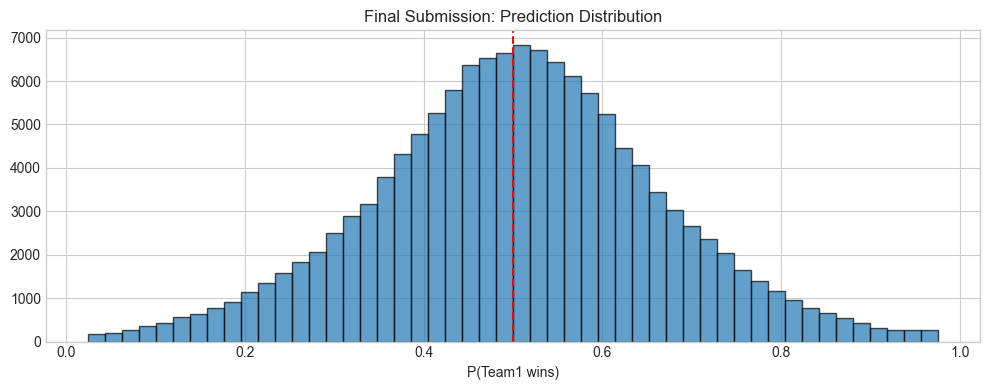

In [22]:
# Generate submission
sub = utils.parse_submission_ids(sample_sub)
sub_enriched = features.create_matchup_df(sub, FINAL_TEAM_FEATURES)
sub_enriched, _ = features.compute_difference_features(sub_enriched)

X_sub = sub_enriched[FINAL_FEATURES].fillna(0).values

if FINAL_MODEL == 'logreg':
    X_sub = final_scaler.transform(X_sub)
    sub_preds = final_model.predict_proba(X_sub)[:, 1]
elif FINAL_MODEL == 'xgb':
    sub_preds = final_model.predict(xgb.DMatrix(X_sub))
elif FINAL_MODEL == 'lgbm':
    sub_preds = final_model.predict(X_sub)

final_sub = utils.generate_submission(
    sub_preds, sample_sub, '../output/submission_refined.csv'
)

# Distribution check
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(final_sub['Pred'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0.5, color='red', linestyle='--')
ax.set_title('Final Submission: Prediction Distribution')
ax.set_xlabel('P(Team1 wins)')
plt.tight_layout()
plt.show()

In [23]:
# Spot-check marquee matchups (using gender='M' to avoid ambiguity)
print("\n" + "="*60)
print("  2026 Matchup Predictions")
print("="*60)

matchups = [
    ('Duke', 'Kentucky', 'M'),
    ('Kansas', 'Connecticut', 'M'),
    ('Gonzaga', 'Houston', 'M'),
    ('Auburn', 'Tennessee', 'M'),
    ('Purdue', 'Alabama', 'M'),
]

for t1, t2, g in matchups:
    id1 = utils.team_id(t1, gender=g)
    id2 = utils.team_id(t2, gender=g)
    if id1 and id2:
        low, high = min(id1, id2), max(id1, id2)
        row = final_sub[final_sub['ID'] == f'2026_{low}_{high}']
        if len(row) > 0:
            p = row['Pred'].values[0]
            n1, n2 = utils.team_name(low), utils.team_name(high)
            winner = n1 if p > 0.5 else n2
            conf = max(p, 1-p)
            print(f"  {n1} vs {n2}: {winner} wins ({conf:.1%})")


  2026 Matchup Predictions
  Duke vs Kentucky: Duke wins (56.8%)
  Connecticut vs Kansas: Connecticut wins (50.6%)
  Gonzaga vs Houston: Gonzaga wins (57.2%)
  Auburn vs Tennessee: Tennessee wins (57.6%)
  Alabama vs Purdue: Purdue wins (56.2%)


---
## Summary & Next Steps

Check the leaderboard above to see which approach won. Key takeaways:

1. **Simple models with strong features > complex models with many features** on small datasets
2. **Multi-year validation** prevents us from fooling ourselves with one lucky holdout
3. **Seed difference alone** is a strong baseline — additions must earn their place
4. **The refinement loop works**: try something → measure on 3 years → keep or drop

### To continue improving:
- Add new experiments by calling `run_experiment()` with different feature/model combos
- Try `model_type='xgb'` with `xgb_conservative` params to test non-linear interactions
- Add Elo ratings, conference strength, coach experience as new features
- Experiment with separate men's/women's models
- Try blending submission with pure seed-based historical win rates